# 🌿 Plant Disease Detection (End-to-End Project)
**Comparative Analysis: Custom CNN vs. Transfer Learning (MobileNetV2)**

This notebook is modularly structured:
1. **Setup & Data:** Download, Load, Augment, and Explore. (Includes Train/Val/Test Split)
2. **Model 1 (Custom CNN):** Architecture, Training, and Evaluation.
3. **Model 2 (MobileNetV2):** Architecture, Training, and Evaluation.
4. **Comparison & Evaluation:** Statistical Evaluation (F1-score, Confusion Matrix) on Unseen Test Data.
5. **Save Models:** Exporting the trained weights for future deployment.

---
## PART 1: Setup & Data Preparation
### 1.1 Data Acquisition from Kaggle

In [1]:
from google.colab import files
import os

print("Please upload your kaggle.json file:")
uploaded = files.upload()

# Setup Kaggle API credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading PlantVillage dataset...")
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

print("Unzipping dataset...")
!unzip -q new-plant-diseases-dataset.zip -d dataset/
print("Dataset is ready!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [01:11<00:00, 40.6MB/s]

Unzipping dataset...
Dataset is ready!


### 1.2 Data Loading & Global Parameters (With Proper Test Split)

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Global Hyperparameters
BATCH_SIZE = 32
IMG_SIZE = (128, 128)
EPOCHS = 20

base_dir = 'dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')

# Load Datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE)

raw_valid_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_dir, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE)

class_names = train_dataset.class_names
num_classes = len(class_names)

# --- Data Isolation: Split raw_valid_dataset into 50% Validation and 50% Test ---
val_batches = tf.data.experimental.cardinality(raw_valid_dataset)
valid_dataset = raw_valid_dataset.take(val_batches // 2)
test_dataset = raw_valid_dataset.skip(val_batches // 2)
print(f"\n✅ Data successfully split! Validation batches: {tf.data.experimental.cardinality(valid_dataset)}, Test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Optimize Datasets for performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
valid_dataset = valid_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# Define Global Data Augmentation Layer
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

# Define Global Early Stopping Callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.

✅ Data successfully split! Validation batches: 275, Test batches: 275


### 1.3 Exploratory Data Analysis (EDA)

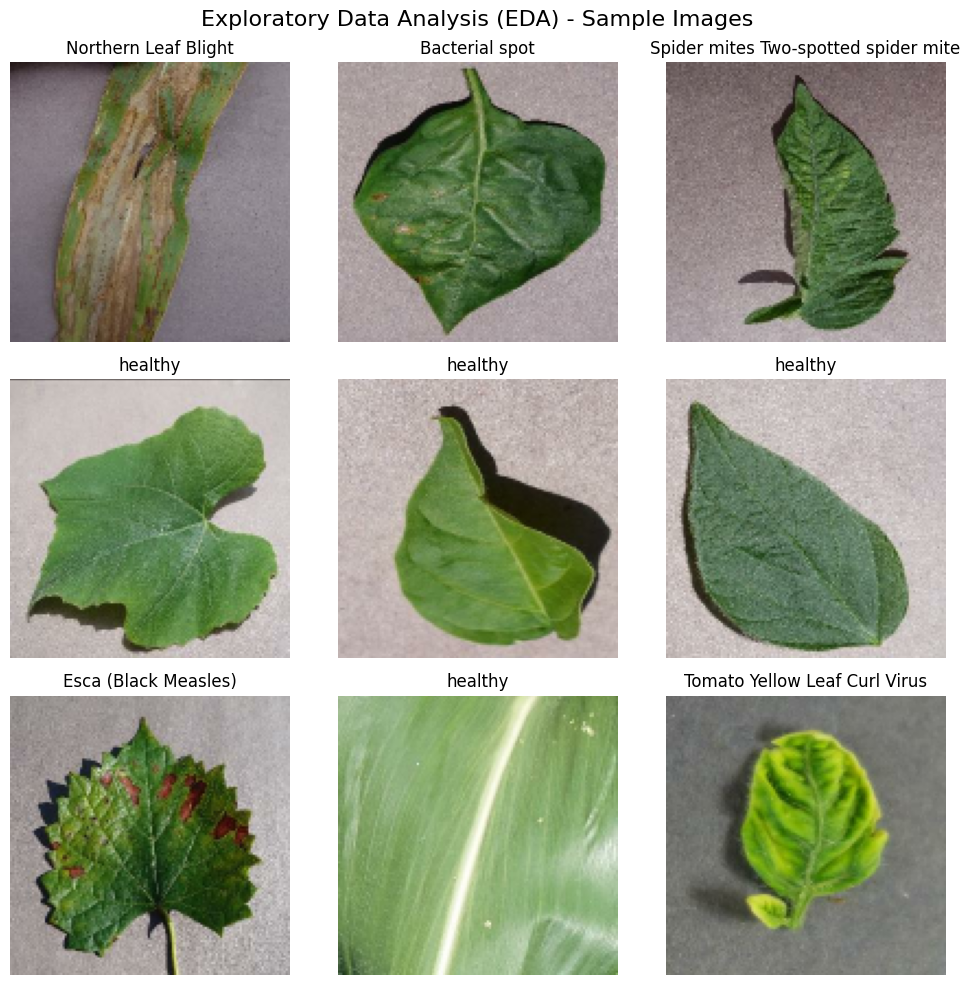

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        clean_name = class_names[labels[i]].split('___')[-1].replace('_', ' ')
        plt.title(clean_name)
        plt.axis("off")
plt.suptitle("Exploratory Data Analysis (EDA) - Sample Images", fontsize=16)
plt.tight_layout()
plt.show()

---
## PART 2: Model 1 - Custom CNN
### 2.1 Custom CNN Architecture

In [4]:
custom_model = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

custom_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
custom_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,525,798 (24.89 MB)

 Trainable params: 6,525,798 (24.89 MB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Custom CNN Training

In [5]:
print("========== Training Custom CNN ==========")
custom_history = custom_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

========== Training Custom CNN ==========
Epoch 1/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 73s 30ms/step - accuracy: 0.5451 - loss: 1.5411 - val_accuracy: 0.7545 - val_loss: 0.7630
Epoch 2/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 86s 34ms/step - accuracy: 0.7711 - loss: 0.7296 - val_accuracy: 0.8737 - val_loss: 0.3923
Epoch 3/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - accuracy: 0.8219 - loss: 0.5602 - val_accuracy: 0.8649 - val_loss: 0.4250
Epoch 4/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 61s 28ms/step - accuracy: 0.8498 - loss: 0.4681 - val_accuracy: 0.8860 - val_loss: 0.3502
Epoch 5/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 66s 30ms/step - accuracy: 0.8710 - loss: 0.4069 - val_accuracy: 0.9275 - val_loss: 0.2178
Epoch 6/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 79s 29ms/step - accuracy: 0.8824 - loss: 0.3635 - val_accuracy: 0.8883 - val_loss: 0.3335
Epoch 7/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.8940 - loss: 0.3291 - val_accuracy: 0.9410 - val_loss: 0.1799
Epoch 8/20
2197/2197 ━━━━━━━━━━━━━

### 2.3 Custom CNN Evaluation

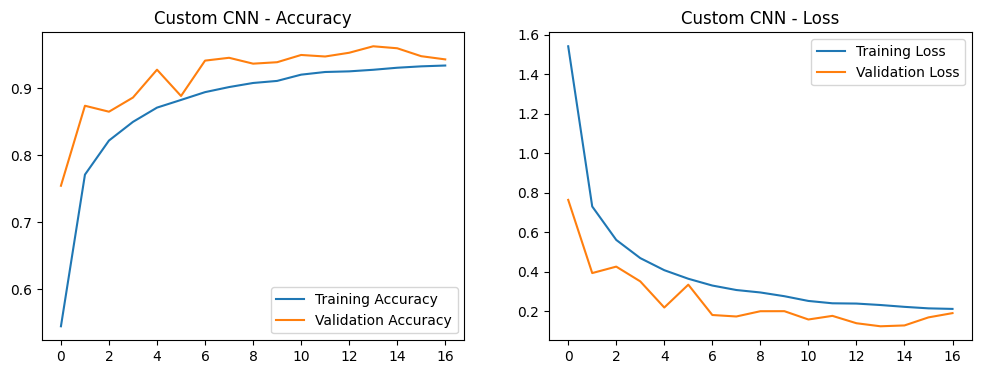

In [6]:
def plot_single_model(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{model_name} - Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{model_name} - Loss')
    plt.show()

plot_single_model(custom_history, "Custom CNN")

---
## PART 3: Model 2 - Transfer Learning (MobileNetV2)
### 3.1 MobileNetV2 Architecture

In [7]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), include_top=False, weights='imagenet'
)
base_model.trainable = False # Freeze base weights

tl_model = models.Sequential([
    layers.InputLayer(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    data_augmentation,
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax')
])

tl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 3.2 MobileNetV2 Training

In [8]:
print("========== Training Transfer Learning Model (MobileNetV2) ==========")
tl_history = tl_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

========== Training Transfer Learning Model (MobileNetV2) ==========
Epoch 1/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 74s 32ms/step - accuracy: 0.8436 - loss: 0.5261 - val_accuracy: 0.8982 - val_loss: 0.3195
Epoch 2/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 66s 30ms/step - accuracy: 0.9040 - loss: 0.2918 - val_accuracy: 0.9030 - val_loss: 0.2938
Epoch 3/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 67s 30ms/step - accuracy: 0.9117 - loss: 0.2690 - val_accuracy: 0.9177 - val_loss: 0.2536


### 3.3 MobileNetV2 Evaluation

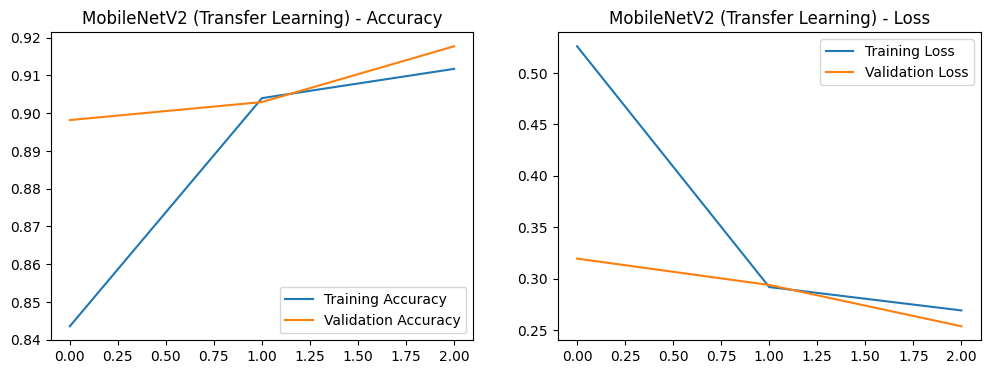

In [9]:
plot_single_model(tl_history, "MobileNetV2 (Transfer Learning)")

---
## PART 4: Comprehensive Comparison & Final Evaluation
### 4.1 Models Comparison (Validation Accuracy)

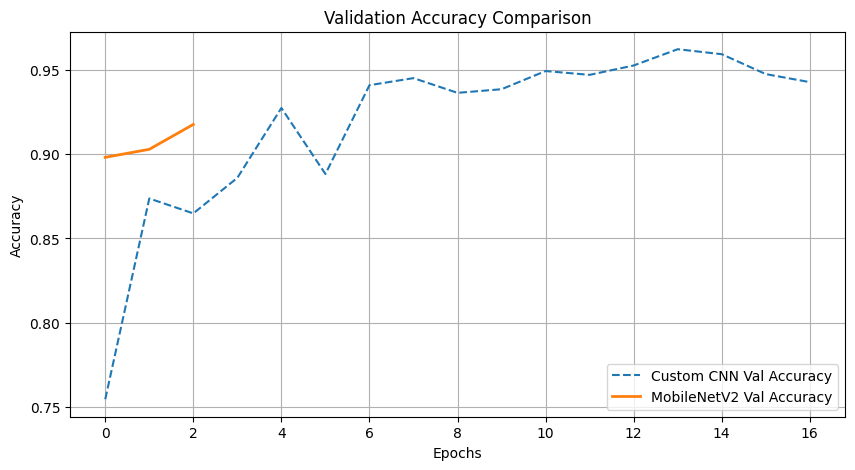

In [10]:
plt.figure(figsize=(10, 5))
epochs_custom = range(len(custom_history.history['val_accuracy']))
epochs_tl = range(len(tl_history.history['val_accuracy']))

plt.plot(epochs_custom, custom_history.history['val_accuracy'], label='Custom CNN Val Accuracy', linestyle='--')
plt.plot(epochs_tl, tl_history.history['val_accuracy'], label='MobileNetV2 Val Accuracy', linewidth=2)

plt.legend(loc='lower right')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

### 4.2 Comprehensive Statistical Evaluation (On UNSEEN Test Set)


🔄 Evaluating Custom CNN on Unseen Test Set...

📊 --- Classification Report: Custom CNN ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.98      0.98       242
                                 Apple___Black_rot       0.98      0.96      0.97       266
                          Apple___Cedar_apple_rust       0.96      0.99      0.98       206
                                   Apple___healthy       1.00      0.98      0.99       241
                               Blueberry___healthy       0.98      0.97      0.98       223
          Cherry_(including_sour)___Powdery_mildew       0.97      0.99      0.98       198
                 Cherry_(including_sour)___healthy       0.92      1.00      0.96       221
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.88      0.91       214
                       Corn_(maize)___Common_rust_       0.98      1.00      0.

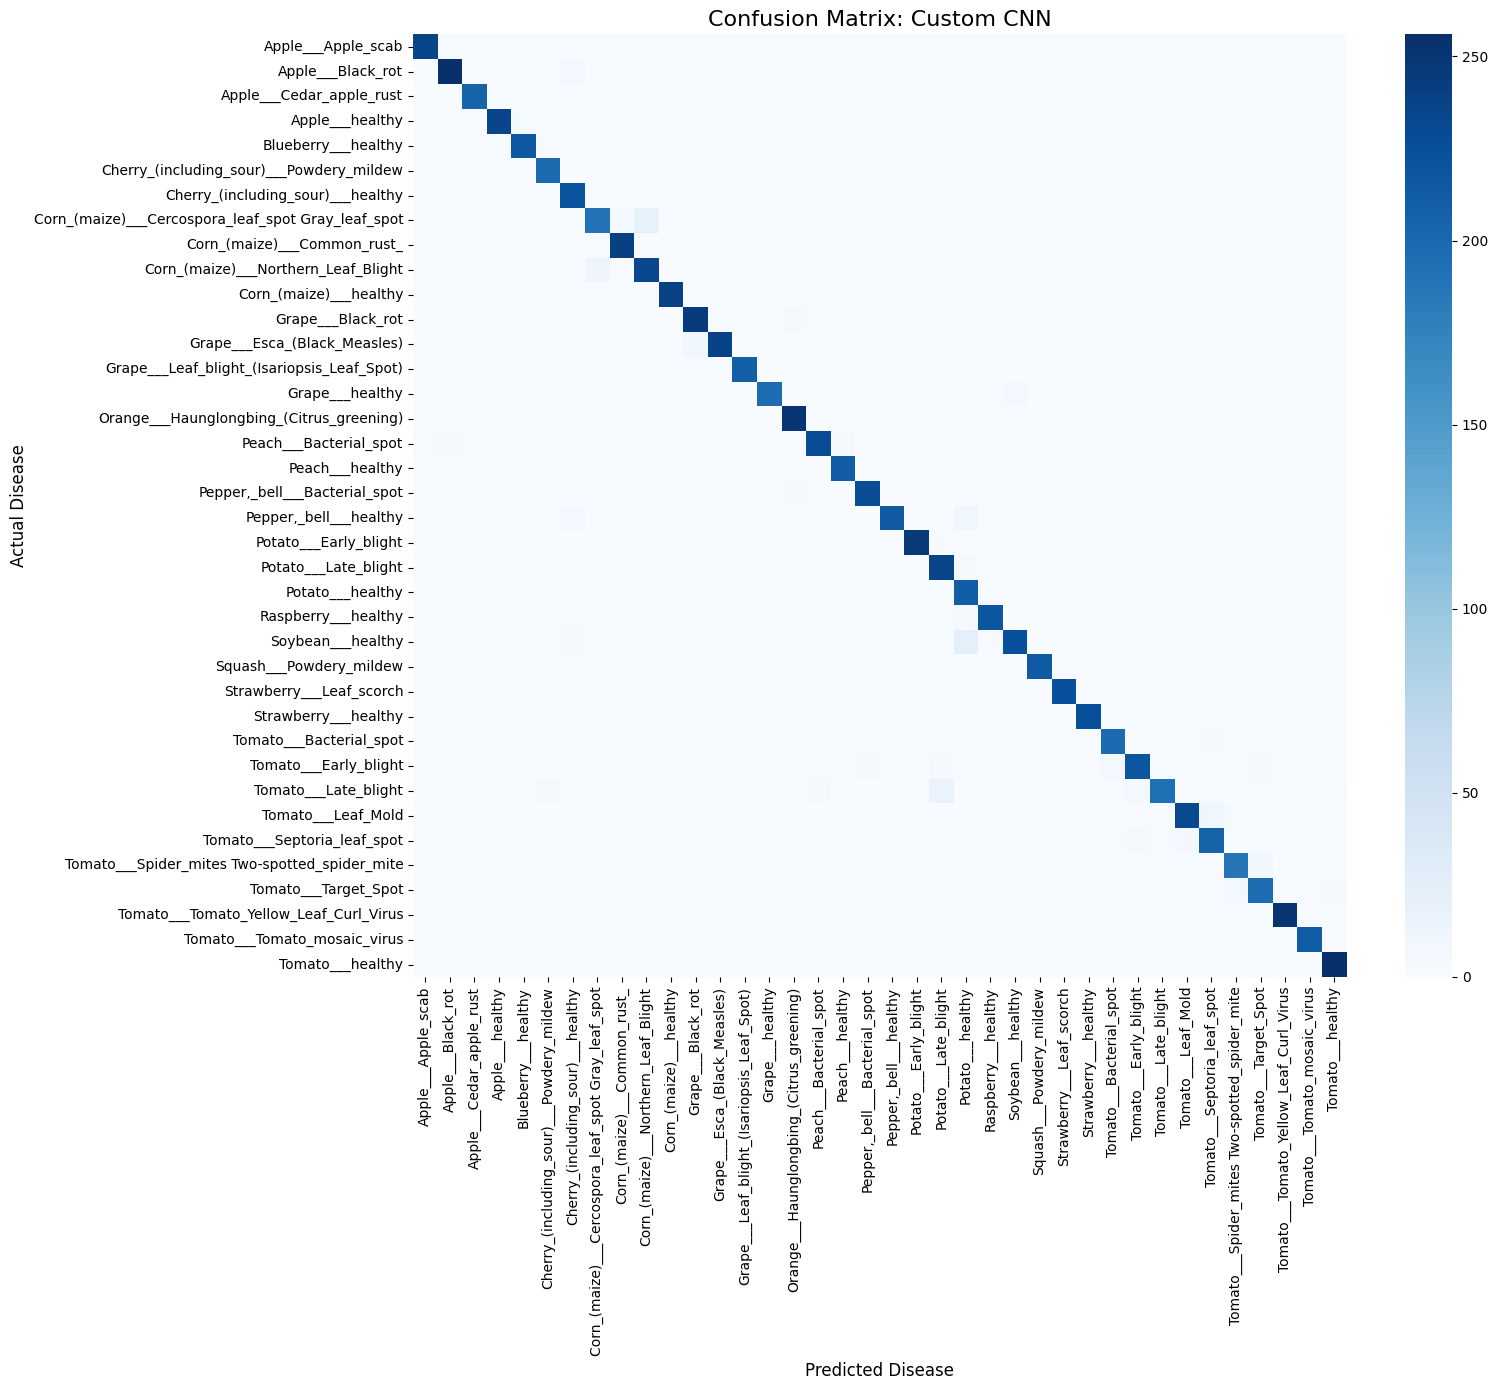


🔄 Evaluating MobileNetV2 on Unseen Test Set...

📊 --- Classification Report: MobileNetV2 ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.89      0.82      0.85       241
                                 Apple___Black_rot       0.97      0.95      0.96       265
                          Apple___Cedar_apple_rust       0.97      0.92      0.94       205
                                   Apple___healthy       0.78      0.97      0.86       241
                               Blueberry___healthy       0.95      0.99      0.97       222
          Cherry_(including_sour)___Powdery_mildew       0.98      0.95      0.96       201
                 Cherry_(including_sour)___healthy       0.99      1.00      0.99       221
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.62      0.75       212
                       Corn_(maize)___Common_rust_       0.99      0.98      

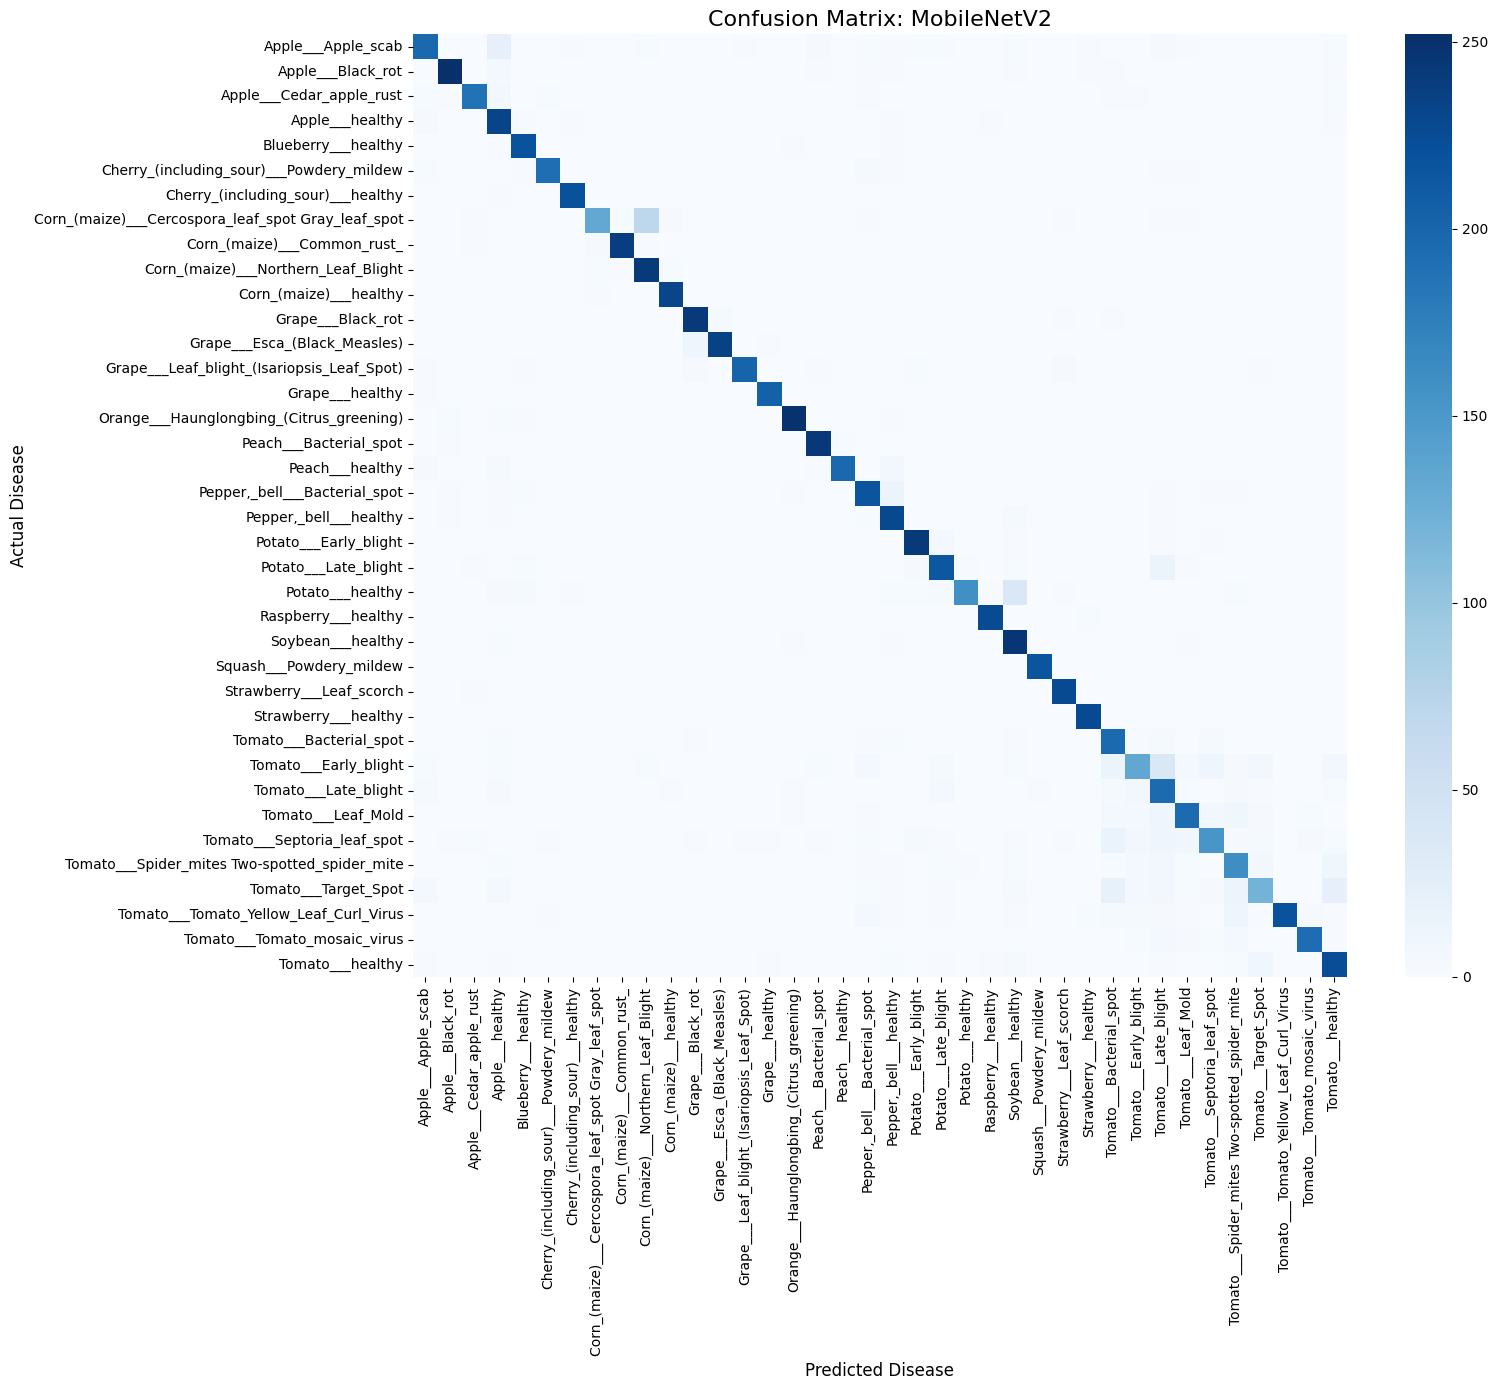

In [11]:
def evaluate_model_comprehensive(model, dataset, model_name):
    print(f"\n========================================================")
    print(f"🔄 Evaluating {model_name} on Unseen Test Set...")
    print(f"========================================================")

    y_true = []
    y_pred = []

    # Extract all true labels and predictions
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # 1. Classification Report
    print(f"\n📊 --- Classification Report: {model_name} ---")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=False, cmap="Blues", fmt="d",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {model_name}', fontsize=16)
    plt.ylabel('Actual Disease', fontsize=12)
    plt.xlabel('Predicted Disease', fontsize=12)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# Run evaluation
evaluate_model_comprehensive(custom_model, test_dataset, "Custom CNN")
evaluate_model_comprehensive(tl_model, test_dataset, "MobileNetV2")

### 4.3 Inference: Testing BOTH Models on a Random Test Image

Testing BOTH models on a random unseen TEST image...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step


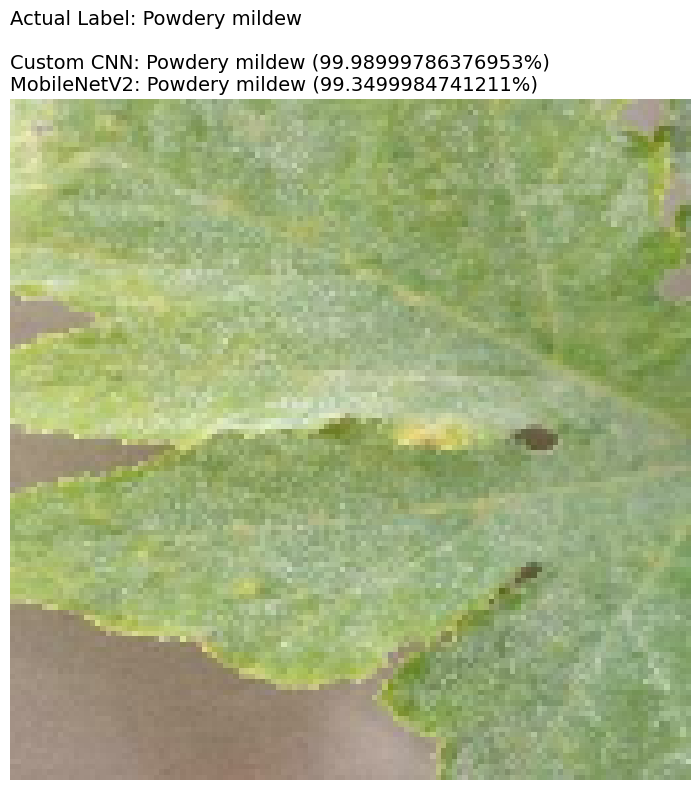

In [12]:
def predict_with_both_models(dataset, custom_model, tl_model):
    # Take a single batch from the test dataset (completely unseen)
    for images, labels in dataset.take(1):
        img = images[0]
        actual_label = class_names[labels[0]].split('___')[-1].replace('_', ' ')

        img_array = tf.expand_dims(img, 0)

        # --- Model 1: Custom CNN Prediction ---
        custom_preds = custom_model.predict(img_array)
        custom_class = class_names[np.argmax(custom_preds[0])].split('___')[-1].replace('_', ' ')
        custom_conf = round(100 * np.max(custom_preds[0]), 2)

        # --- Model 2: MobileNetV2 Prediction ---
        tl_preds = tl_model.predict(img_array)
        tl_class = class_names[np.argmax(tl_preds[0])].split('___')[-1].replace('_', ' ')
        tl_conf = round(100 * np.max(tl_preds[0]), 2)

        # --- Display Results ---
        plt.figure(figsize=(8, 8))
        plt.imshow(img.numpy().astype("uint8"))

        title_text = (
            f"Actual Label: {actual_label}\n\n"
            f"Custom CNN: {custom_class} ({custom_conf}%)\n"
            f"MobileNetV2: {tl_class} ({tl_conf}%)"
        )

        plt.title(title_text, fontsize=14, loc='left')
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        break

print("Testing BOTH models on a random unseen TEST image...")
predict_with_both_models(test_dataset, custom_model, tl_model)

---
## PART 5: Save Models
### 5.1 Export Weights for Future Deployment

In [13]:
print("Saving models...")

custom_model.save('best_custom_cnn_final.keras')
tl_model.save('best_mobilenet_final.keras')

print("Models saved successfully! 🎉")
print("You can now open the Files icon on the left to download them to your local device.")

Saving models...
Models saved successfully! 🎉
You can now open the Files icon on the left to download them to your local device.
